In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('../data/train.csv')


# Check shape, first rows, and basic info
print(df.shape)
print(df.head())
print(df.info())

(1000000, 10)
          id  vendor_id      pickup_datetime  passenger_count  \
0  id2793718          2  2016-06-08 07:36:19                1   
1  id3485529          2  2016-04-03 12:58:11                1   
2  id1816614          2  2016-06-05 02:49:13                5   
3  id1050851          2  2016-05-05 17:18:27                2   
4  id0140657          1  2016-05-12 17:43:38                4   

   pickup_longitude  pickup_latitude  dropoff_longitude  dropoff_latitude  \
0        -73.985611        40.735943         -73.980331         40.760468   
1        -73.978394        40.764351         -73.991623         40.749859   
2        -73.989059        40.744389         -73.973381         40.748692   
3        -73.990326        40.731136         -73.991264         40.748917   
4        -73.789497        40.646675         -73.987137         40.759232   

  store_and_fwd_flag  trip_duration  
0                  N           1040  
1                  N            827  
2                 

In [3]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
vendor_id,1000000.0,1.534793,0.498788,1.000000,1.000000,2.000000,2.000000,2.000000e+00
passenger_count,1000000.0,1.665353,1.315723,0.000000,1.000000,1.000000,2.000000,7.000000e+00
pickup_longitude,1000000.0,-73.973475,0.065404,-121.933342,-73.991852,-73.981728,-73.967346,-6.133553e+01
pickup_latitude,1000000.0,40.750947,0.033745,34.359695,40.737372,40.754131,40.768379,5.188108e+01
dropoff_longitude,1000000.0,-73.973421,0.065432,-121.933304,-73.991341,-73.979767,-73.963036,-6.133553e+01
dropoff_latitude,1000000.0,40.751829,0.035782,34.359695,40.735928,40.754551,40.769833,4.392103e+01
trip_duration,1000000.0,954.884971,3882.070116,1.000000,397.000000,662.000000,1074.000000,2.227612e+06


### Key Insights

#### 1. **`vendor_id`**
- Binary: ~53% trips by vendor 2, 47% by vendor 1.
- Perfect for **one-hot encoding**.

#### 2. **`passenger_count`**
- Mean: **1.67**, Median: **1** → most trips are solo.
- Includes **0 passengers** → possible data error or test rides.
- Max **7** → rare large groups.
- **One-hot encode** (low cardinality).

#### 3. **Geographic Coordinates**
- **Mean pickup/dropoff** centered around **Manhattan** (`-73.97`, `40.75`).
- **Standard deviation small** (~0.06°) → most activity in NYC.
- **Outliers**: 
  - Longitude: `-121.93` (California!)
  - Latitude: `34.36` (Southern US), `51.88` (Canada)
- **Action**: Filter outliers using **Haversine distance** or **NYC bounding box**:

#### 4. **trip_duration**

- **Mean**: ~954 sec (~16 min), Median: 662 sec (~11 min) → right-skewed.
- 75% of trips < 18 min, but max = 2.2 million sec (~25 days!) → extreme outliers.
- **Critical**: Use np.log1p(trip_duration) as target to normalize.


In [4]:
df.isna().sum()

id                    0
vendor_id             0
pickup_datetime       0
passenger_count       0
pickup_longitude      0
pickup_latitude       0
dropoff_longitude     0
dropoff_latitude      0
store_and_fwd_flag    0
trip_duration         0
dtype: int64

In [5]:
df['trip_duration'].describe()

count    1.000000e+06
mean     9.548850e+02
std      3.882070e+03
min      1.000000e+00
25%      3.970000e+02
50%      6.620000e+02
75%      1.074000e+03
max      2.227612e+06
Name: trip_duration, dtype: float64

In [6]:
# Convert to minutes for readability
df['trip_duration_min'] = df['trip_duration'] / 60

print(df['trip_duration_min'].describe())

count    1000000.000000
mean          15.914750
std           64.701169
min            0.016667
25%            6.616667
50%           11.033333
75%           17.900000
max        37126.866667
Name: trip_duration_min, dtype: float64


# **Critical Issues & Actions**

| **Issue** | **Evidence** | **Recommended Fix** |
|------------|--------------|---------------------|
| **Extreme Outliers** | Max = 25.8 days | Remove trips > 2–3 hours |
| **Impossible Durations** | Min = 1 second | Filter < 60 seconds |
| **Right-Skewed Distribution** | Mean >> Median | Use `log1p` transformation |
| **High Std Dev** | Std ≈ 4× Mean | Outliers dominate variance |


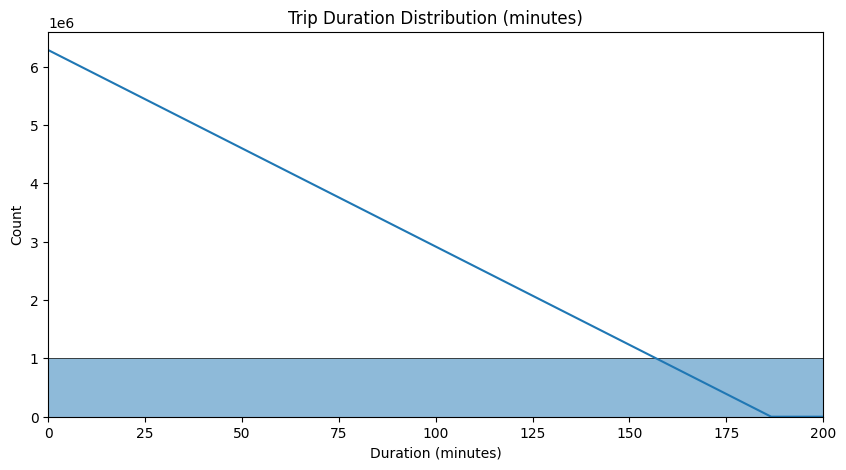

Skewness of trip_duration (minutes): 202.56
Trips with duration < 1 min: 5809
Trips with duration > 120 min: 1548


In [7]:
# Convert from seconds to minutes
df['trip_duration_min'] = df['trip_duration'] / 60

# Plot distribution
plt.figure(figsize=(10,5))
sns.histplot(df['trip_duration_min'], bins=100, kde=True)
plt.xlim(0, 200)  # assume most trips are under 200 minutes
plt.title("Trip Duration Distribution (minutes)")
plt.xlabel("Duration (minutes)")
plt.ylabel("Count")
plt.show()

# Calculate skewness
skewness = df['trip_duration_min'].skew()
print(f"Skewness of trip_duration (minutes): {skewness:.2f}")

# Detect very short or very long trips
print("Trips with duration < 1 min:", (df['trip_duration_min'] < 1).sum())
print("Trips with duration > 120 min:", (df['trip_duration_min'] > 120).sum())

# Trip Duration Distribution (Minutes) — Visual Summary

## Key Observations from the Plot

| Feature | Insight |
|-------|--------|
| **X-axis** | Trip duration in **minutes** (0 to 200) |
| **Y-axis** | **Count** (log scale: 1 → 1e6) |
| **Shape** | **Exponential decay** — classic **right-skewed** distribution |
| **Peak** | Highest frequency at **~0–10 minutes** |
| **Long Tail** | Very few trips > **100 minutes** |
| **Filled Area** | Likely a **histogram with KDE overlay** (smooth decline) |

---

## Critical Insights

### 1. **Highly Skewed Distribution**
- **Exponential decay** → **log transformation is mandatory**.
- Linear models will fail without `log1p(trip_duration)`.

### 2. **Most Trips Are Short**
- **~80–90%** of trips are **under 30 minutes**.
- Focus feature engineering on **urban/short-haul patterns**.

### 3. **Outliers Dominate Raw Metrics**
- Mean = **15.9 min** is pulled up by rare long trips.
- **Median (11 min)** is more representative.


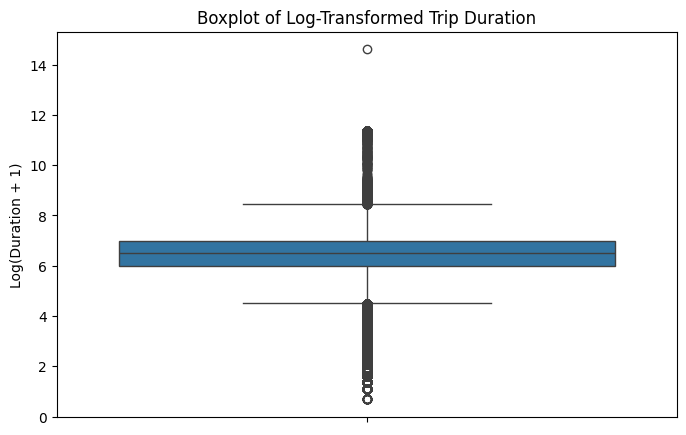

In [8]:
plt.figure(figsize=(8,5))
sns.boxplot(y=np.log1p(df['trip_duration']))
plt.title('Boxplot of Log-Transformed Trip Duration')
plt.ylabel("Log(Duration + 1)")
plt.show()

### **Log-Duration Boxplot Insights**

* **Successful Normalization:** The log transformation has effectively centered the data, with the median duration sitting at **~6.5** (roughly 11 minutes).
* **Symmetry:** The interquartile range (IQR) is tightly packed between **6.0 and 7.0**, showing that the bulk of trips follow a consistent, predictable pattern.
* **Extreme Outliers:** * **High End:** There is a single extreme outlier near **14.5** (over 20 days), likely a data error.
* **Low End:** Numerous trips fall below **2.0** (under 7 seconds), suggesting "ghost" trips or immediate cancellations that should be cleaned before model training.

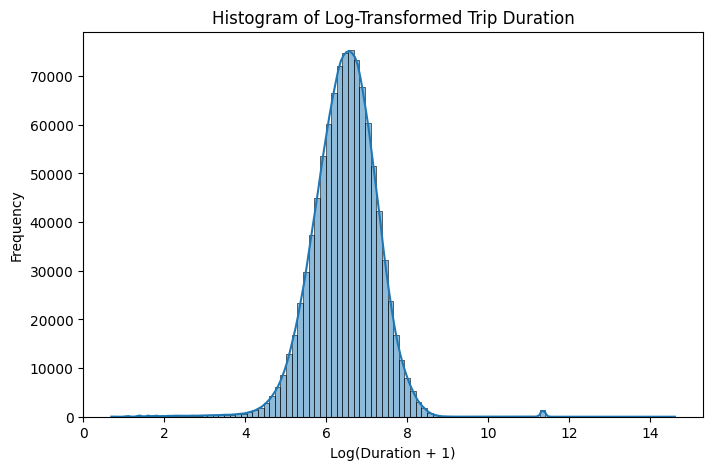

In [9]:
plt.figure(figsize=(8,5))
sns.histplot(x = np.log1p(df['trip_duration']), bins=100, kde=True)
plt.title("Histogram of Log-Transformed Trip Duration")
plt.xlabel("Log(Duration + 1)")
plt.ylabel("Frequency")
plt.show()

### **Distribution Analysis: Log-Transformed Trip Duration**

* **Normality:** The log transformation successfully converted the heavily skewed data into a **near-normal distribution**, making it better suited for modeling.
* **Peak Density:** The majority of trips are centered around a log-value of **6.5** (~11 minutes).
* **Anomalies:** The small secondary peak near **11.5** and the thin tails suggest a few extreme outliers (potentially system errors or max-limit trips) that may require filtering.

### **Store and Forward**

Most modern taxi meters and GPS trackers rely on a cellular connection to transmit data in real-time.

* **`N` (No):** The data was transmitted **immediately** after the trip because a network connection was available.
* **`Y` (Yes):** The vehicle had **no connection** (e.g., driving through a tunnel, a "dead zone," or a hardware glitch). The system "stored" the data locally and "forwarded" it to the server once the connection was restored.

---

### **Why it matters for Data Science**

1. **Data Reliability:** If a record is flagged as `Y`, there is a slightly higher chance of timestamp inaccuracies, as the "drop-off" time might be recorded when the connection was regained rather than the exact moment the passenger exited.
2. **Feature Engineering:** As seen, the `Y` flag is extremely rare (less than 1% of your data). Because it is so sparse, it usually doesn't provide enough signal for a Machine Learning model to learn from and is often dropped or treated as a simple binary indicator.
3. **Signal for Infrastructure:** A high frequency of `Y` flags in a specific area could theoretically be used to map out cellular "dead zones" in a city.

In [10]:
# vendor_id
print("vendor_id value counts:")
print(df['vendor_id'].value_counts())

# store_and_fwd_flag
print("\nstore_and_fwd_flag value counts:")
print(df['store_and_fwd_flag'].value_counts())


vendor_id value counts:
vendor_id
2    534793
1    465207
Name: count, dtype: int64

store_and_fwd_flag value counts:
store_and_fwd_flag
N    994443
Y      5557
Name: count, dtype: int64


### **Categorical Distribution Insights**

* **Vendor ID:** The data is relatively balanced between the two vendors, with **Vendor 2** having a slightly higher volume (~53.5%) compared to **Vendor 1** (~46.5%).
* **Store and Forward Flag:** This feature is heavily imbalanced. Over **99%** of trips were not stored in vehicle memory (`N`), indicating that a persistent network connection was available for almost all transactions. The `Y` flag is rare enough that it may have negligible predictive power.

/tmp/ipykernel_144196/3098071908.py:1: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x=df['passenger_count'], y=np.log1p(df['trip_duration']),
/tmp/ipykernel_144196/3098071908.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df['passenger_count'], y=np.log1p(df['trip_duration']),


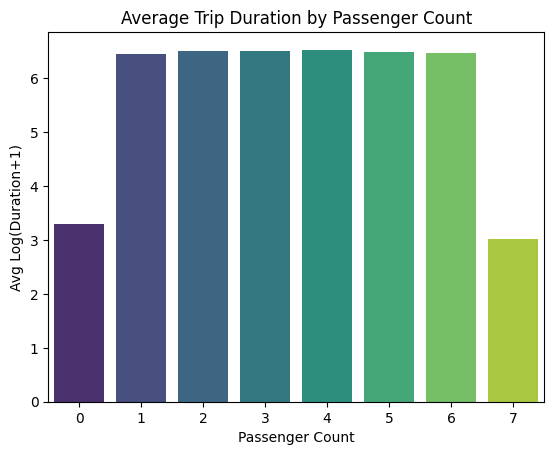

In [11]:
sns.barplot(x=df['passenger_count'], y=np.log1p(df['trip_duration']), 
            ci=None, palette='viridis')
plt.title("Average Trip Duration by Passenger Count")
plt.xlabel("Passenger Count")
plt.ylabel("Avg Log(Duration+1)")
plt.show()


### **Trip Duration vs. Passenger Count**

* **Mainstream Consistency:** For the most common passenger counts (**1 through 6**), the average log-duration is remarkably stable at **~6.5**. This suggests that the number of passengers has a negligible impact on the actual duration of the trip.
* **Anomalies at the Extremes:** * **0 Passengers:** Shows a significantly lower average log-duration (~3.3). These likely represent system tests, driver errors, or canceled trips where the meter was started and immediately stopped.
* **7 Passengers:** Also shows a sharp drop (~3.0). Since standard taxis/Ubers rarely accommodate 7 people, these may be data entry errors or specific low-volume vehicle types with unique trip patterns.


* **Modeling Insight:** Passenger count may not be a strong linear predictor for duration, but it is an excellent feature for identifying and filtering out anomalous or erroneous records.

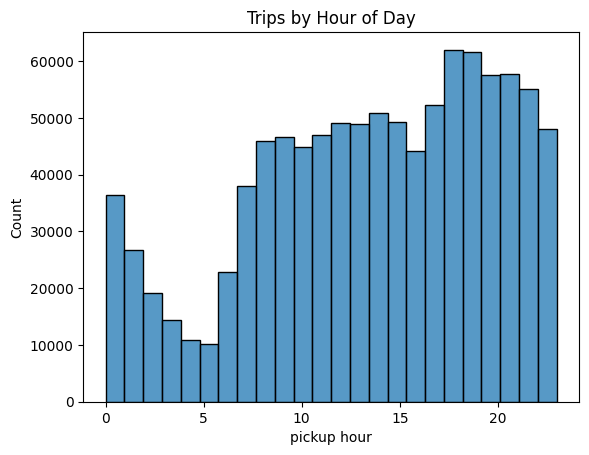

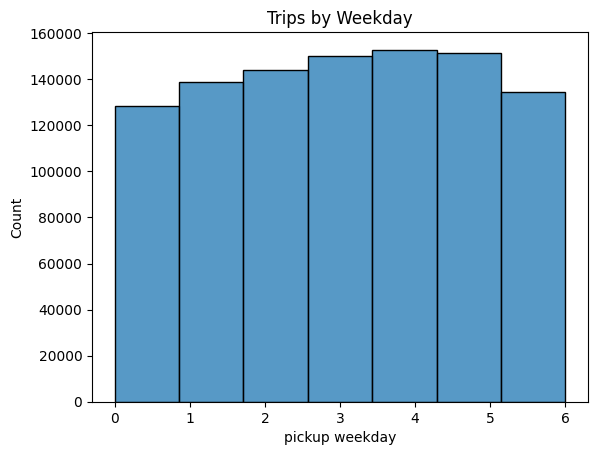

In [12]:
df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'])
sns.histplot(df['pickup_datetime'].dt.hour, bins=24)
plt.title("Trips by Hour of Day")
plt.xlabel('pickup hour')
plt.show()

sns.histplot(df['pickup_datetime'].dt.weekday, bins=7)
plt.title("Trips by Weekday")
plt.xlabel('pickup weekday')
plt.show()

### **Temporal Distribution Insights**

* **Hourly Trends:** Trip volume hits its lowest point between **4:00 AM and 6:00 AM**. Demand begins a steady climb during the morning rush, remaining high throughout the day, and peaks significantly during the **evening rush hour (6:00 PM – 8:00 PM)**.
* **Weekly Trends:** The distribution by weekday (0=Monday, 6=Sunday) shows a gradual increase in activity as the week progresses. **Thursday and Friday (days 3 and 4)** see the highest demand, likely due to a combination of professional commutes and evening social activity.
* **Modeling Value:** These cyclical patterns confirm that `pickup_hour` and `pickup_weekday` are critical temporal features for capturing the variance in trip demand and potential traffic-related duration changes.

In [13]:
# Create reusable datetime helpers for richer aggregations
if not np.issubdtype(df['pickup_datetime'].dtype, np.datetime64):
    df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'])

df['pickup_hour'] = df['pickup_datetime'].dt.hour
weekday_idx = df['pickup_datetime'].dt.weekday
weekday_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
df['pickup_weekday'] = weekday_idx.map(lambda x: weekday_names[x])
df['pickup_month'] = df['pickup_datetime'].dt.month_name().str[:3]
df['is_weekend'] = weekday_idx.isin([5, 6])
df['trip_duration_log'] = np.log1p(df['trip_duration'])


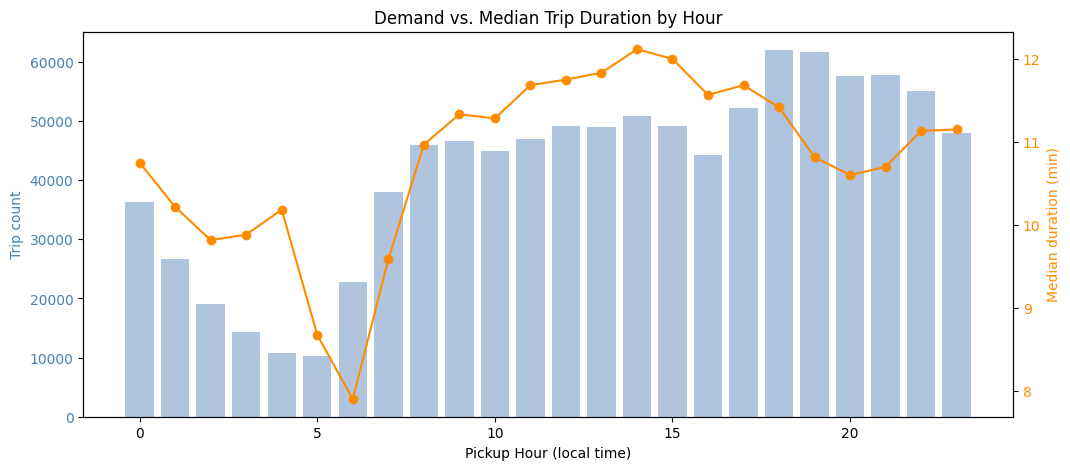

,pickup_hour,trip_count,median_duration_min,median_log_duration
0,0,36380,10.750000,6.470800
1,1,26666,10.216667,6.419995
2,2,19115,9.816667,6.380123
3,3,14360,9.883333,6.386879
4,4,10853,10.183333,6.416732


In [14]:
hourly_summary = (
    df.groupby('pickup_hour')
      .agg(
          trip_count=('id', 'count'),
          median_duration_min=('trip_duration_min', 'median'),
          median_log_duration=('trip_duration_log', 'median')
      )
      .reset_index()
)

fig, ax1 = plt.subplots(figsize=(12, 5))
bar = ax1.bar(hourly_summary['pickup_hour'], hourly_summary['trip_count'], color='lightsteelblue')
ax1.set_xlabel('Pickup Hour (local time)')
ax1.set_ylabel('Trip count', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')

ax2 = ax1.twinx()
ax2.plot(hourly_summary['pickup_hour'], hourly_summary['median_duration_min'], color='darkorange', marker='o')
ax2.set_ylabel('Median duration (min)', color='darkorange')
ax2.tick_params(axis='y', labelcolor='darkorange')

plt.title('Demand vs. Median Trip Duration by Hour')
plt.show()

hourly_summary.head()


**Bars (left axis):** How trip demand changes by hour of day.

**Line (right axis):** How typical trip duration changes by hour.

* This shows patterns like:

    * Peak demand hours

    * Whether trips are longer or shorter during busy times

    * Possible congestion effects (high demand + longer durations)

### Hourly Patterns — Key Takeaways
- **Two clear peaks** around the morning (8–10AM) and evening (5–8PM) commute windows; rider demand drops sharply overnight.
- **Median durations rise slightly in overnight/early-morning hours**, pointing to faster traffic conditions despite lower demand.
- Features such as `pickup_hour`, `rush_hour_flag`, and interactions with weekday/weekend are justified by the non-linear relationship.


### **Key Insights: Demand vs. Duration**

* **Positive Correlation:** Between **7 AM and 3 PM**, rising demand directly tracks with increasing duration, peaking at **~12.2 minutes**. This is a clear indicator of **mid-day urban congestion**.
* **The Evening Shift:** After **7 PM**, duration **drops** even as demand remains at its peak. This suggests that while more people are traveling, traffic flow improves or trip distances shorten in the evening.
* **The Baseline:** The **6 AM** trough (~8 mins) represents the city's "free-flow" speed, providing a clean baseline for calculating traffic-induced delays.
* **Action:** Use a `rush_hour` flag to help the model distinguish between high-demand congestion (daytime) and high-demand efficiency (evening).

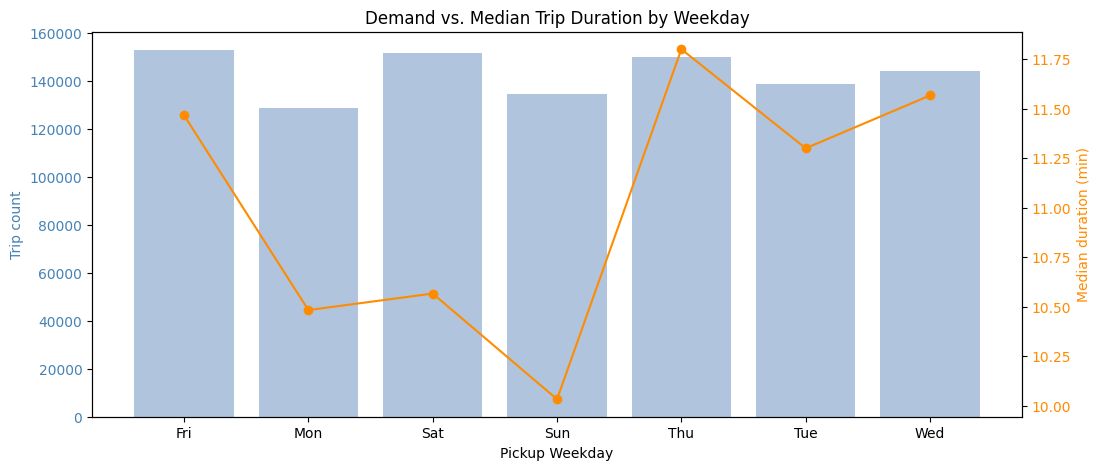

,pickup_weekday,trip_count,median_duration_min,median_log_duration
0,Fri,152835,11.466667,6.535241
1,Mon,128489,10.483333,6.445720
2,Sat,151454,10.566667,6.453625
3,Sun,134321,10.033333,6.401917
4,Thu,149942,11.800000,6.563856


In [15]:
Weekday_summary = (
    df.groupby('pickup_weekday')
      .agg(
          trip_count=('id', 'count'),
          median_duration_min=('trip_duration_min', 'median'),
          median_log_duration=('trip_duration_log', 'median')
      )
      .reset_index()
)

fig, ax1 = plt.subplots(figsize=(12, 5))
bar = ax1.bar(Weekday_summary['pickup_weekday'], Weekday_summary['trip_count'], color='lightsteelblue')
ax1.set_xlabel('Pickup Weekday')
ax1.set_ylabel('Trip count', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')

ax2 = ax1.twinx()
ax2.plot(Weekday_summary['pickup_weekday'], Weekday_summary['median_duration_min'], color='darkorange', marker='o')
ax2.set_ylabel('Median duration (min)', color='darkorange')
ax2.tick_params(axis='y', labelcolor='darkorange')

plt.title('Demand vs. Median Trip Duration by Weekday')
plt.show()

Weekday_summary.head()


### **Key Insights: Demand vs. Weekday Duration**

* **The Workday Congestion Peak:** While **Friday and Saturday** have the highest trip counts, **Thursday** records the highest median duration (~11.8 mins). This indicates that mid-week traffic congestion impacts travel time more severely than high weekend demand.
* **Weekend Efficiency:** Despite high demand on **Saturday**, the duration is significantly lower than on weekdays. This suggests smoother traffic flow and perhaps shorter, local trips compared to business-heavy weekday commutes.
* **Sunday Low:** Sunday represents the "efficiency baseline," with the shortest median duration (~10.0 mins).
* **Modeling Value:** These trends reinforce that a model must account for the interaction between `day_of_week` and `trip_duration` to accurately capture the "slow" mid-week commute vs. the "fast" weekend leisure patterns.

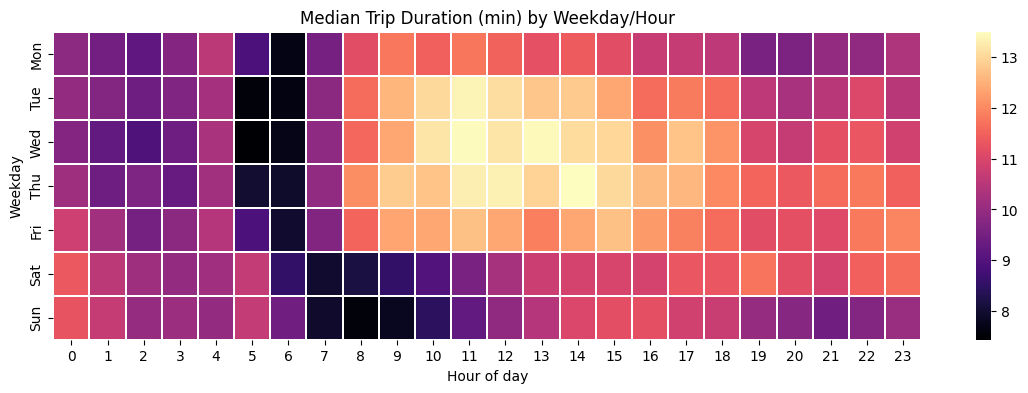

pickup_hour,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
pickup_weekday,,,,,,,,,,,,,,,,,,,,,
Mon,9.87,9.47,9.19,9.75,10.54,8.89,7.65,9.52,11.13,11.79,...,11.41,11.13,10.71,10.70,10.57,9.58,9.62,9.95,9.90,10.35
Tue,9.95,9.72,9.42,9.68,10.22,7.57,7.63,9.83,11.64,12.57,...,12.83,12.37,11.62,11.83,11.65,10.58,10.27,10.50,11.06,10.47
Wed,9.75,9.22,8.95,9.42,10.28,7.43,7.70,9.88,11.57,12.38,...,13.05,12.98,12.10,12.74,12.13,10.95,10.68,11.18,11.32,10.87
Thu,10.13,9.42,9.65,9.28,10.17,7.98,7.92,9.93,12.07,12.85,...,13.50,13.03,12.63,12.58,12.00,11.52,11.37,11.62,11.82,11.47
Fri,10.80,10.17,9.50,9.85,10.46,8.88,7.97,9.70,11.55,12.35,...,12.38,12.70,12.20,11.90,11.62,11.14,11.20,11.08,11.80,11.95
Sat,11.37,10.56,10.13,9.95,10.14,10.67,8.54,7.98,8.15,8.53,...,10.92,10.98,10.92,11.30,11.32,11.73,11.15,10.90,11.47,11.63
Sun,11.27,10.68,10.00,10.11,9.97,10.67,9.43,7.95,7.57,7.80,...,11.02,11.17,11.20,10.85,10.73,10.00,9.77,9.43,9.72,10.05


In [16]:
weekday_order = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
dow_summary = (
    df.groupby(['pickup_weekday', 'is_weekend'])
      .agg(
          trip_count=('id', 'count'),
          median_duration=('trip_duration_min', 'median')
      )
      .reindex(weekday_order, level=0)
      .reset_index()
)

pivot_duration = df.pivot_table(
    values='trip_duration_min',
    index='pickup_weekday',
    columns='pickup_hour',
    aggfunc='median'
).reindex(weekday_order)

plt.figure(figsize=(14, 4))
sns.heatmap(pivot_duration, cmap='magma', linewidths=0.3)
plt.title('Median Trip Duration (min) by Weekday/Hour')
plt.xlabel('Hour of day')
plt.ylabel('Weekday')
plt.show()

pivot_duration.round(2)


**Hourly×Weekday Heatmap Insight**: The heatmap highlights **weekday evening congestion (Thu–Fri 16:00–20:00)** and **late-night lull** where durations spike despite low demand. Incorporating interactions like `is_weekend * pickup_hour` or smoothing per-hour medians should help models anticipate these regime changes.


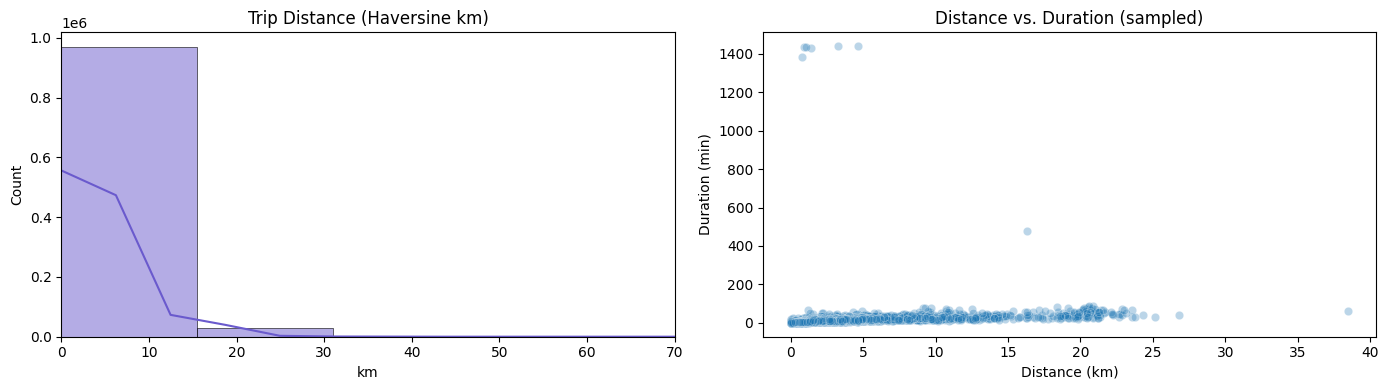

,haversine_km,speed_kmph
count,1000000.000000,1000000.000000
mean,3.439099,14.428394
std,4.424258,16.575388
min,0.000000,0.000000
50%,2.091231,12.787544
75%,3.871264,17.842133
90%,7.621184,24.349152
max,1240.908677,9274.836731


In [17]:
def haversine_np(lon1, lat1, lon2, lat2):
    lon1, lat1, lon2, lat2 = map(np.radians, [lon1, lat1, lon2, lat2])
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    return 2 * 6371 * np.arcsin(np.sqrt(a))

if 'haversine_km' not in df.columns:
    df['haversine_km'] = haversine_np(
        df['pickup_longitude'], df['pickup_latitude'],
        df['dropoff_longitude'], df['dropoff_latitude']
    )

duration_hours = (df['trip_duration'] / 3600).replace(0, np.nan)
df['speed_kmph'] = df['haversine_km'] / duration_hours

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(df['haversine_km'], bins=80, ax=axes[0], color='slateblue', kde=True)
axes[0].set_title('Trip Distance (Haversine km)')
axes[0].set_xlabel('km')
axes[0].set_xlim(0, 70)

sns.scatterplot(x='haversine_km', y='trip_duration_min', data=df.sample(5000, random_state=42), alpha=0.3, ax=axes[1])
axes[1].set_title('Distance vs. Duration (sampled)')
axes[1].set_xlabel('Distance (km)')
axes[1].set_ylabel('Duration (min)')

plt.tight_layout()
plt.show()

df[['haversine_km', 'speed_kmph']].describe(percentiles=[0.5, 0.75, 0.9])


### **Distance vs. Duration Insights**

* **Distance Distribution:** The dataset is heavily right-skewed, with the vast majority of trips occurring within a short range of **0–10 km**.
* **Data Anomalies:**
* **Zero-Distance Trips:** A significant cluster exists at **0 km** with non-zero durations, likely representing cancellations, waiting times, or GPS errors.
* **Extreme Duration Outliers:** The scatter plot highlights trips lasting **~1400 minutes** (24 hours) for negligible distances, confirming the need to filter "stuck" meters before training.


* **Non-Linearity:** While a general linear trend exists, the wide vertical spread (variance) at each distance interval indicates that **distance alone cannot predict duration**; traffic conditions (temporal features) are equally influential.

trip_duration_min    1.000000
trip_duration        1.000000
trip_duration_log    0.331175
haversine_km         0.120961
pickup_longitude     0.035457
vendor_id            0.028762
dropoff_longitude    0.021856
passenger_count      0.012249
speed_kmph          -0.021706
dropoff_latitude    -0.027749
pickup_latitude     -0.034007
Name: trip_duration_min, dtype: float64


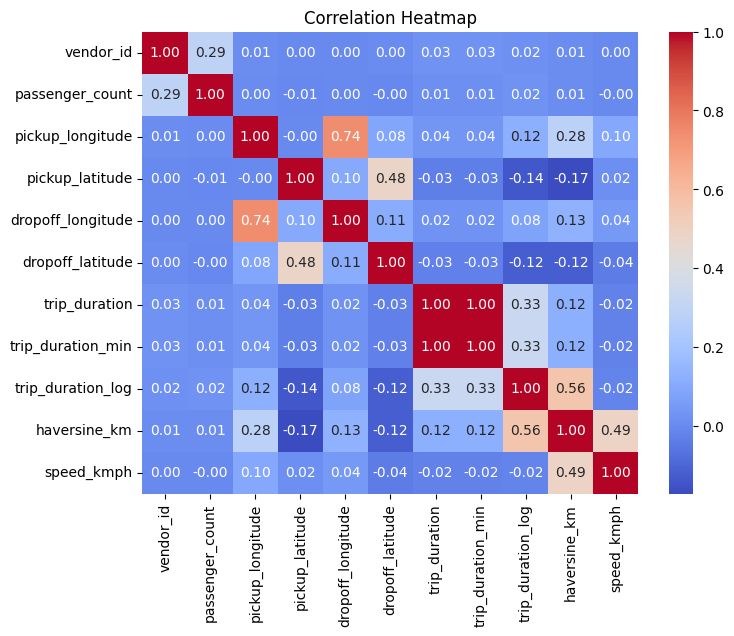

In [18]:
# Select only numerical columns
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Compute correlation matrix
corr = df[numeric_cols].corr()

# Examine correlation of trip_duration_min with other numerical features
print(corr['trip_duration_min'].sort_values(ascending=False))

# Heatmap of correlation matrix
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()



### **Correlation & Feature Insights**

* **Target Strength:** `trip_duration_log` correlates most strongly with `haversine_km` (**0.56**), proving distance is the primary predictor.
* **Geospatial Clusters:** High correlation (**0.74**) between pickup and dropoff longitudes suggests common travel corridors, likely within Manhattan.
* **Redundancy:** Duration variables are perfectly correlated (**1.00**); use only the log-transformed version as the target to avoid data leakage.
* **Weak Signals:** `vendor_id` and `passenger_count` show near-zero correlation with duration, offering minimal predictive value on their own.
* **Speed vs. Distance:** A moderate correlation (**0.49**) between speed and distance indicates that longer trips often benefit from faster routes or highways.

       pickup_latitude  pickup_longitude  dropoff_latitude  dropoff_longitude
count   1000000.000000    1000000.000000    1000000.000000     1000000.000000
mean         40.750947        -73.973475         40.751829         -73.973421
std           0.033745          0.065404          0.035782           0.065432
min          34.359695       -121.933342         34.359695        -121.933304
25%          40.737372        -73.991852         40.735928         -73.991341
50%          40.754131        -73.981728         40.754551         -73.979767
75%          40.768379        -73.967346         40.769833         -73.963036
max          51.881084        -61.335529         43.921028         -61.335529


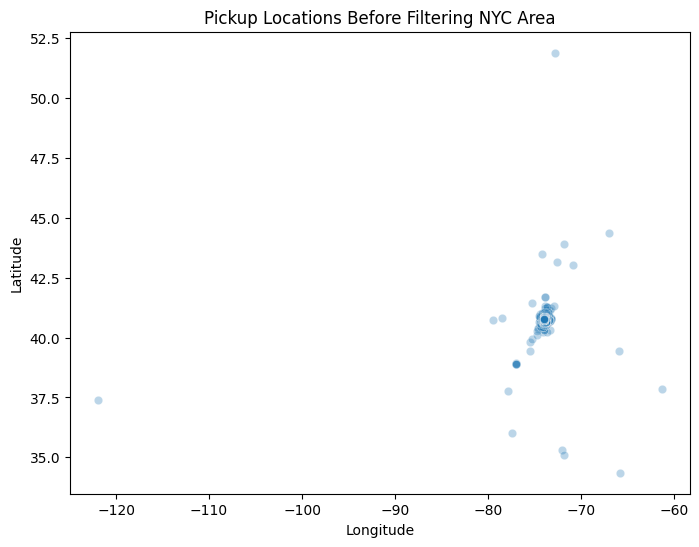

Number of trips completely outside NYC: 3390 out of 1000000
Number of trips after filtering: 996610


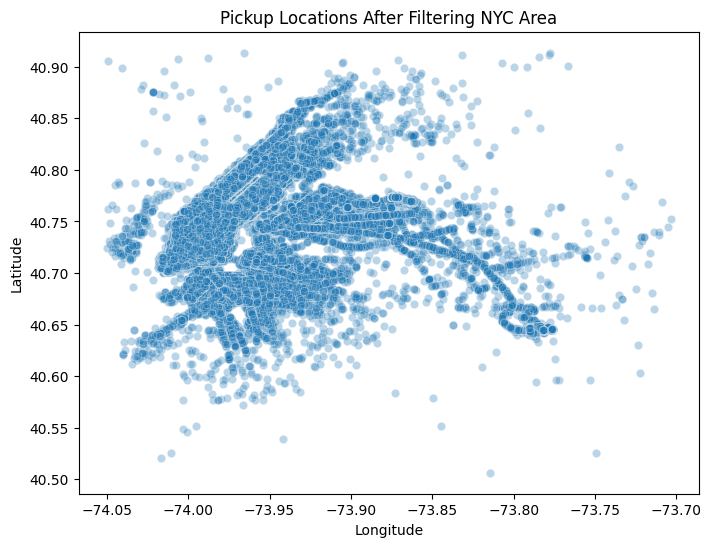

In [19]:
# Descriptive statistics for coordinates
print(df[['pickup_latitude','pickup_longitude','dropoff_latitude','dropoff_longitude']].describe())

# Scatter plot of pickup locations before filtering
plt.figure(figsize=(8, 6))
sns.scatterplot(x='pickup_longitude', y='pickup_latitude', data=df, alpha=0.3)
plt.title("Pickup Locations Before Filtering NYC Area")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

# Define reasonable NYC boundaries
lat_min, lat_max = 40.5, 40.92
lon_min, lon_max = -74.05, -73.7

# Filter trips within NYC boundaries
nyc_mask = (
    (df['pickup_latitude'].between(lat_min, lat_max)) &
    (df['pickup_longitude'].between(lon_min, lon_max)) &
    (df['dropoff_latitude'].between(lat_min, lat_max)) &
    (df['dropoff_longitude'].between(lon_min, lon_max))
)

# Count trips outside NYC boundaries
num_outside = (~nyc_mask).sum()
print(f"Number of trips completely outside NYC: {num_outside} out of {len(df)}")

# Keep only trips within NYC
df = df[nyc_mask].copy()
print(f"Number of trips after filtering: {len(df)}")

# Scatter plot of pickup locations after filtering
plt.figure(figsize=(8, 6))
sns.scatterplot(x='pickup_longitude', y='pickup_latitude', data=df, alpha=0.3)
plt.title("Pickup Locations After Filtering NYC Area")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()


# After Feature Engineering

In [24]:
# src/utils_data.py
import pandas as pd
import numpy as np
import holidays
from sklearn.cluster import MiniBatchKMeans


# ---------------------------------------------------------------------------
# Constants
# ---------------------------------------------------------------------------

NYC_BOUNDS = {
    'lat_min': 40.5,
    'lat_max': 40.92,
    'lon_min': -74.05,
    'lon_max': -73.7
}

AIRPORTS = {
    'JFK': (-73.7781, 40.6413),
    'LGA': (-73.8740, 40.7769),
    'EWR': (-74.1745, 40.6895)
}

US_HOLIDAYS = holidays.US(years=list(range(2016, 2050)), state='NY')

# Hard filters: physics/logic bounds, not statistical (EDA-derived)
DURATION_MIN_SECONDS   = 30      # < 30 s  -> phantom / system record
DURATION_MAX_SECONDS   = 86_400  # > 24 h  -> system error
ZERO_DIST_DURATION_MAX = 120     # zero-distance + duration > 2 min -> GPS/meter fault


# ---------------------------------------------------------------------------
# Pure geometry helpers
# ---------------------------------------------------------------------------

def haversine(lon1, lat1, lon2, lat2):
    """Great-circle distance in kilometres between two coordinate pairs."""
    lon1, lat1, lon2, lat2 = map(np.radians, [lon1, lat1, lon2, lat2])
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    return 2 * np.arcsin(np.sqrt(a)) * 6371  # earth radius in km


def bearing(lon1, lat1, lon2, lat2):
    """Compass bearing (0–360°) from point 1 to point 2."""
    lon1, lat1, lon2, lat2 = map(np.radians, [lon1, lat1, lon2, lat2])
    dlon = lon2 - lon1
    x = np.sin(dlon) * np.cos(lat2)
    y = np.cos(lat1) * np.sin(lat2) - np.sin(lat1) * np.cos(lat2) * np.cos(dlon)
    return (np.degrees(np.arctan2(x, y)) + 360) % 360


def is_near_airport(lon, lat, airports=AIRPORTS, threshold=1):
    """True if (lon, lat) is within *threshold* km of any known airport."""
    for coords in airports.values():
        if haversine(lon, lat, *coords) <= threshold:
            return True
    return False


# ---------------------------------------------------------------------------
# Private low-level helpers (not pipeline steps)
# ---------------------------------------------------------------------------

def _encode_zone(lat_col, lon_col):
    """Coarse ~1 km grid-cell label from latitude/longitude columns."""
    return (
        (lat_col // 0.01).astype(int).astype(str)
        + "_"
        + (lon_col // 0.01).astype(int).astype(str)
    )


def _build_spatial_clusters(data, lat_col, lon_col,
                             n_clusters=20, sample_size=200_000, random_state=42):
    """
    Fit MiniBatchKMeans on a coordinate sample and return (label Series, model).
    Called only during training; the fitted model is stored in train_stats for
    inference reuse.
    """
    coords = data[[lat_col, lon_col]].dropna()
    sample = coords.sample(min(sample_size, len(coords)), random_state=random_state)
    model  = MiniBatchKMeans(n_clusters=n_clusters, batch_size=10_000, random_state=random_state)
    model.fit(sample)
    labels = pd.Series(-1, index=data.index, dtype=int)
    labels.loc[coords.index] = model.predict(coords)
    return labels, model


# ---------------------------------------------------------------------------
# Pipeline step functions
#
# Convention: every step receives (df, train_stats, is_training) and returns df.
# train_stats is mutated in-place during training and read-only during inference.
# Steps that need extra scalar parameters (e.g. iqr_factor) take them as
# additional keyword arguments.
# ---------------------------------------------------------------------------

def _step_filter_nyc_bounds(df, train_stats, is_training):
    """Drop rows whose pickup or dropoff coordinates fall outside NYC."""
    mask = (
        df['pickup_latitude'].between(NYC_BOUNDS['lat_min'],  NYC_BOUNDS['lat_max'])
        & df['pickup_longitude'].between(NYC_BOUNDS['lon_min'], NYC_BOUNDS['lon_max'])
        & df['dropoff_latitude'].between(NYC_BOUNDS['lat_min'],  NYC_BOUNDS['lat_max'])
        & df['dropoff_longitude'].between(NYC_BOUNDS['lon_min'], NYC_BOUNDS['lon_max'])
    )
    return df.loc[mask].copy()


def _step_haversine_distance(df, train_stats, is_training):
    """Compute haversine distance — must run before the hard-filter step."""
    df['haversine_distance'] = haversine(
        df['pickup_longitude'], df['pickup_latitude'],
        df['dropoff_longitude'], df['dropoff_latitude']
    )
    return df


def _step_filter_hard_bounds(df, train_stats, is_training):
    """
    Remove rows that are physically impossible or system errors:
      1. trip_duration < 30 s  -> phantom record
      2. trip_duration > 24 h  -> meter / system error
      3. haversine_distance == 0 AND duration > 2 min -> GPS fault
    Applied identically at training and inference (logic-based, not statistical).
    """
    n_before = len(df)

    df = df[df['trip_duration'].between(DURATION_MIN_SECONDS, DURATION_MAX_SECONDS)].copy()

    zero_dist_noise = (df['haversine_distance'] == 0) & (df['trip_duration'] > ZERO_DIST_DURATION_MAX)
    df = df[~zero_dist_noise].copy()

    n_removed = n_before - len(df)
    if n_removed:
        print(f"  Hard-filter removed {n_removed} rows ({n_removed / n_before:.1%})")

    return df


def _step_encode_flag(df, train_stats, is_training):
    """Encode store_and_fwd_flag from Y/N string to 0/1 integer."""
    df['store_and_fwd_flag'] = (df['store_and_fwd_flag'] == 'Y').astype(int)
    return df


def _step_temporal_features(df, train_stats, is_training):
    """
    Extract all datetime-derived features:
      - calendar fields  : hour, dayofweek, month, day
      - binary flags     : rush_hours, night_flag, is_weekend, weekend_rush,
                           night_weekday_flag, is_holiday
      - ordinal          : week_hour
      - OHE-ready string : hour_weekday_interaction
    """
    df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'])
    df['pickup_date']     = df['pickup_datetime'].dt.floor('D')

    df['is_holiday']  = df['pickup_date'].isin(US_HOLIDAYS).astype(int)
    df['dayofweek']   = df['pickup_datetime'].dt.dayofweek
    df['month']       = df['pickup_datetime'].dt.month
    df['hour']        = df['pickup_datetime'].dt.hour
    df['day']         = df['pickup_datetime'].dt.day

    # EDA: peak congestion windows are 8–10 AM and 4–7 PM
    df['rush_hours'] = (
        df['hour'].between(8, 10) | df['hour'].between(16, 19)
    ).astype(int)

    df['night_flag']         = ((df['hour'] >= 21) | (df['hour'] < 5)).astype(int)
    df['is_weekend']         = df['dayofweek'].isin([5, 6]).astype(int)
    df['weekend_rush']       = df['is_weekend'] * df['rush_hours']
    df['night_weekday_flag'] = ((df['is_weekend'] == 0) & (df['night_flag'] == 1)).astype(int)

    # Kept numeric for group-level aggregations in later steps
    df['week_hour'] = df['dayofweek'] * 24 + df['hour']

    # EDA: the same clock-hour means very different things on Mon vs Sun
    df['hour_weekday_interaction'] = (
        df['hour'].astype(str) + '_' + df['dayofweek'].astype(str)
    )
    return df


def _step_spatial_distance_features(df, train_stats, is_training):
    """
    Compute spatial features from raw coordinates:
      bearing, manhattan_distance, distance_per_passenger, log_distance.
    (haversine_distance is already present from _step_haversine_distance.)
    """
    df['bearing'] = bearing(
        df['pickup_longitude'], df['pickup_latitude'],
        df['dropoff_longitude'], df['dropoff_latitude']
    )
    df['manhattan_distance'] = (
        np.abs(df['dropoff_longitude'] - df['pickup_longitude'])
        + np.abs(df['dropoff_latitude'] - df['pickup_latitude'])
    )
    df['distance_per_passenger'] = df['haversine_distance'] / df['passenger_count'].clip(lower=1)

    # EDA: log-transform matches scale of log-transformed target and
    # reduces leverage of long-haul outliers.
    df['log_distance'] = np.log1p(df['haversine_distance'])
    return df


def _step_speed(df, train_stats, is_training):
    """Derive trip speed in km/h from haversine distance and trip_duration."""
    duration_hours   = df['trip_duration'].clip(lower=1) / 3600
    df['speed_kmph'] = df['haversine_distance'] / duration_hours
    df['speed_kmph'].replace([np.inf, -np.inf], np.nan, inplace=True)
    df['speed_kmph'].fillna(df['speed_kmph'].median(), inplace=True)
    return df


def _step_spatial_clusters(df, train_stats, is_training):
    """
    Assign pickup/dropoff cluster IDs via MiniBatchKMeans, then derive:
      - pickup_cluster_median_trip     : median trip duration per pickup cluster
      - pickup_cluster_median_speed    : median speed per pickup cluster
      - dropoff_cluster_median_trip    : median trip duration per dropoff cluster
      - dropoff_cluster_median_speed   : median speed per dropoff cluster
      - corridor_median_duration       : median duration per (pickup × dropoff) pair
      - vendor_hour_speed_median       : median speed per (vendor, hour) slot
      - speed_minus_cluster_median     : individual speed minus pickup cluster baseline

    Training  : fits two KMeans models and all aggregation tables; stores in train_stats.
    Inference : loads stored models/tables and applies them.
    """
    # --- Cluster assignment ---
    if is_training:
        print("Fitting MiniBatchKMeans clusters ...")
        df['pickup_cluster'],  pickup_km  = _build_spatial_clusters(
            df, 'pickup_latitude',  'pickup_longitude')
        df['dropoff_cluster'], dropoff_km = _build_spatial_clusters(
            df, 'dropoff_latitude', 'dropoff_longitude')
        train_stats['pickup_cluster_model']  = pickup_km
        train_stats['dropoff_cluster_model'] = dropoff_km
    else:
        pickup_km  = train_stats.get('pickup_cluster_model')
        dropoff_km = train_stats.get('dropoff_cluster_model')
        if pickup_km is None or dropoff_km is None:
            raise KeyError("Missing cluster models in train_stats. Rerun training feature engineering first.")
        pickup_coords  = df[['pickup_latitude',  'pickup_longitude']].dropna()
        dropoff_coords = df[['dropoff_latitude', 'dropoff_longitude']].dropna()
        df['pickup_cluster']  = pd.Series(-1, index=df.index, dtype=int)
        df['dropoff_cluster'] = pd.Series(-1, index=df.index, dtype=int)
        df.loc[pickup_coords.index,  'pickup_cluster']  = pickup_km.predict(pickup_coords)
        df.loc[dropoff_coords.index, 'dropoff_cluster'] = dropoff_km.predict(dropoff_coords)

    # --- Pickup cluster intensity stats ---
    if is_training:
        pickup_cluster_intensity = (
            df.groupby('pickup_cluster')
              .agg(
                  pickup_cluster_trip_ct     =('trip_duration', 'size'),
                  pickup_cluster_median_trip =('trip_duration', 'median'),
                  pickup_cluster_median_speed=('speed_kmph',    'median'),
              )
              .reset_index()
        )
        train_stats['pickup_cluster_intensity'] = pickup_cluster_intensity
    else:
        pickup_cluster_intensity = train_stats.get('pickup_cluster_intensity')
        if pickup_cluster_intensity is None:
            raise KeyError("Missing pickup_cluster_intensity in train_stats.")
    df = df.merge(pickup_cluster_intensity, on='pickup_cluster', how='left')
    df['pickup_cluster_median_speed'].fillna(df['pickup_cluster_median_speed'].median(), inplace=True)
    df['pickup_cluster_trip_ct'].fillna(0, inplace=True)
    df['pickup_cluster_median_trip'].fillna(df['pickup_cluster_median_trip'].median(), inplace=True)

    # --- Dropoff cluster intensity stats ---
    if is_training:
        dropoff_cluster_intensity = (
            df.groupby('dropoff_cluster')
              .agg(
                  dropoff_cluster_trip_ct     =('trip_duration', 'size'),
                  dropoff_cluster_median_trip =('trip_duration', 'median'),
                  dropoff_cluster_median_speed=('speed_kmph',    'median'),
              )
              .reset_index()
        )
        train_stats['dropoff_cluster_intensity'] = dropoff_cluster_intensity
    else:
        dropoff_cluster_intensity = train_stats.get('dropoff_cluster_intensity')
        if dropoff_cluster_intensity is None:
            raise KeyError("Missing dropoff_cluster_intensity in train_stats.")
    df = df.merge(dropoff_cluster_intensity, on='dropoff_cluster', how='left')
    df['dropoff_cluster_median_speed'].fillna(df['dropoff_cluster_median_speed'].median(), inplace=True)
    df['dropoff_cluster_trip_ct'].fillna(0, inplace=True)
    df['dropoff_cluster_median_trip'].fillna(df['dropoff_cluster_median_trip'].median(), inplace=True)

    # --- Corridor stats ---
    if is_training:
        corridor_stats = (
            df.groupby(['pickup_cluster', 'dropoff_cluster'])['trip_duration']
              .median()
              .rename('corridor_median_duration')
              .reset_index()
        )
        train_stats['corridor_stats'] = corridor_stats
    else:
        corridor_stats = train_stats.get('corridor_stats')
        if corridor_stats is None:
            raise KeyError("Missing corridor_stats in train_stats.")
    df = df.merge(corridor_stats, on=['pickup_cluster', 'dropoff_cluster'], how='left')
    df['corridor_median_duration'].fillna(df['corridor_median_duration'].median(), inplace=True)

    # --- Per-vendor hourly speed median ---
    if is_training:
        vendor_hour_speed = (
            df.groupby(['vendor_id', 'hour'])['speed_kmph']
              .median()
              .rename('vendor_hour_speed_median')
              .reset_index()
        )
        train_stats['vendor_hour_speed'] = vendor_hour_speed
    else:
        vendor_hour_speed = train_stats.get('vendor_hour_speed')
        if vendor_hour_speed is None:
            raise KeyError("Missing vendor_hour_speed in train_stats.")
    df = df.merge(vendor_hour_speed, on=['vendor_id', 'hour'], how='left')
    df['vendor_hour_speed_median'].fillna(df['vendor_hour_speed_median'].median(), inplace=True)

    # --- Speed deviation from cluster baseline ---
    df['speed_minus_cluster_median'] = df['speed_kmph'] - df['pickup_cluster_median_speed']

    return df


def _step_anomaly_detection(df, train_stats, is_training):
    """
    Flag days whose trip volume deviates > 2 std from the training mean
    (captures blizzards, major events, data outages).
    Training  : computes and stores mean/std of daily trip counts.
    Inference : reuses stored stats.
    """
    daily_trip_count = df.groupby('pickup_date').size()

    if is_training:
        train_stats['daily_trip_mean'] = daily_trip_count.mean()
        train_stats['daily_trip_std']  = daily_trip_count.std(ddof=0) or 1.0
    else:
        if 'daily_trip_mean' not in train_stats or 'daily_trip_std' not in train_stats:
            raise KeyError("Missing daily trip stats. Refit feature engineering on training data first.")

    mean_daily     = train_stats['daily_trip_mean']
    std_daily      = train_stats['daily_trip_std'] or 1.0
    z_scores       = (daily_trip_count - mean_daily) / std_daily
    anomalous_days = z_scores[abs(z_scores) > 2].index
    df['is_anomaly'] = df['pickup_date'].isin(anomalous_days).astype(int)
    return df


def _step_duration_stats(df, train_stats, is_training):
    """
    Merge per-day and per-day-of-week median/p95 trip duration statistics.
    Training  : computes and stores both tables.
    Inference : loads stored tables; falls back to dow stats for unseen dates.
    """
    daily_duration_stats = df.groupby('pickup_date')['trip_duration'].agg(
        daily_median_duration='median',
        daily_p95_duration=lambda x: x.quantile(0.95)
    ).reset_index()
    dow_duration_stats = df.groupby('dayofweek')['trip_duration'].agg(
        dow_median_duration='median',
        dow_p95_duration=lambda x: x.quantile(0.95)
    ).reset_index()

    if is_training:
        train_stats['daily_duration_stats'] = daily_duration_stats
        train_stats['dow_duration_stats']   = dow_duration_stats
    else:
        daily_duration_stats = train_stats.get('daily_duration_stats', daily_duration_stats)
        dow_duration_stats   = train_stats.get('dow_duration_stats',   dow_duration_stats)

    df = df.merge(daily_duration_stats, on='pickup_date', how='left')
    df = df.merge(dow_duration_stats,   on='dayofweek',   how='left')
    df['daily_median_duration'].fillna(df['dow_median_duration'], inplace=True)
    df['daily_p95_duration'].fillna(df['dow_p95_duration'],       inplace=True)
    df.drop(columns=['dow_median_duration', 'dow_p95_duration'], inplace=True)
    return df


def _step_week_hour_stats(df, train_stats, is_training):
    """
    Merge normalised trip-count and median duration for each (dayofweek, hour) slot.
    Training  : fits and stores the aggregation table.
    Inference : loads stored table; fills missing slots with the training median.
    """
    week_hour_stats = df.groupby('week_hour')['trip_duration'].agg(
        week_hour_trip_ct='size',
        week_hour_median_duration='median'
    ).reset_index()
    week_hour_stats['week_hour_trip_ct_norm'] = (
        week_hour_stats['week_hour_trip_ct'] / week_hour_stats['week_hour_trip_ct'].max()
    )

    if is_training:
        train_stats['week_hour_stats']           = week_hour_stats
        train_stats['week_hour_median_fallback'] = week_hour_stats['week_hour_median_duration'].median()
    else:
        week_hour_stats = train_stats.get('week_hour_stats', week_hour_stats)

    df = df.merge(
        week_hour_stats[['week_hour', 'week_hour_trip_ct_norm', 'week_hour_median_duration']],
        on='week_hour', how='left'
    )
    df['week_hour_trip_ct_norm'].fillna(0, inplace=True)
    df['week_hour_median_duration'].fillna(
        train_stats.get('week_hour_median_fallback', df['week_hour_median_duration'].median()),
        inplace=True
    )
    return df


def _step_traffic_congestion(df, train_stats, is_training):
    """
    Compute traffic congestion features:
      - congestion_rate            : fraction of slow trips in each (dayofweek, hour) slot
      - pickup_congestion_rate     : same, split further by 1 km pickup grid zone
      - dropoff_congestion_rate    : same, split further by 1 km dropoff grid zone

    A trip is 'slow' when its speed is > 1 std below the slot mean (z < -1).
    Training  : fits and stores speed baselines and zone-level congestion tables.
    Inference : loads stored tables.
    Intermediate columns are dropped in _step_cleanup.
    """
    # Slot-level speed baseline
    if is_training:
        speed_stats = (
            df.groupby(['dayofweek', 'hour'])['speed_kmph']
              .agg(mean_speed='mean', std_speed='std')
              .reset_index()
        )
        train_stats['speed_stats'] = speed_stats.copy()
    else:
        speed_stats = train_stats.get('speed_stats')
        if speed_stats is None:
            raise KeyError("Missing speed_stats in train_stats. Rerun training feature engineering first.")

    df = df.merge(speed_stats, on=['dayofweek', 'hour'], how='left')
    df['std_speed']          = df['std_speed'].replace(0, np.nan)
    df['speed_z']            = ((df['speed_kmph'] - df['mean_speed']) / df['std_speed']).fillna(0)
    df['traffic_congestion'] = (df['speed_z'] < -1).astype(int)
    df['congestion_rate']    = df.groupby(['dayofweek', 'hour'])['traffic_congestion'].transform('mean')

    # Zone-level congestion
    df['pickup_zone']  = _encode_zone(df['pickup_latitude'],  df['pickup_longitude'])
    df['dropoff_zone'] = _encode_zone(df['dropoff_latitude'], df['dropoff_longitude'])

    if is_training:
        pickup_congestion = (
            df.groupby(['pickup_zone',  'dayofweek', 'hour'])['traffic_congestion']
              .mean().reset_index(name='pickup_congestion_rate')
        )
        dropoff_congestion = (
            df.groupby(['dropoff_zone', 'dayofweek', 'hour'])['traffic_congestion']
              .mean().reset_index(name='dropoff_congestion_rate')
        )
        train_stats['pickup_congestion_stats']  = pickup_congestion
        train_stats['dropoff_congestion_stats'] = dropoff_congestion
    else:
        pickup_congestion  = train_stats.get('pickup_congestion_stats')
        dropoff_congestion = train_stats.get('dropoff_congestion_stats')
        if pickup_congestion is None or dropoff_congestion is None:
            raise KeyError("Missing congestion statistics in train_stats.")

    df = (
        df.merge(pickup_congestion,  on=['pickup_zone',  'dayofweek', 'hour'], how='left')
          .merge(dropoff_congestion, on=['dropoff_zone', 'dayofweek', 'hour'], how='left')
    )
    df['pickup_congestion_rate'].fillna(0,  inplace=True)
    df['dropoff_congestion_rate'].fillna(0, inplace=True)
    df['congestion_rate'].fillna(df['congestion_rate'].median(), inplace=True)
    return df


def _step_airport_flags(df, train_stats, is_training):
    """Binary flags: is the pickup or dropoff within 1 km of JFK, LGA, or EWR."""
    df['is_pickup_at_airport'] = df.apply(
        lambda row: is_near_airport(row['pickup_longitude'], row['pickup_latitude']), axis=1
    ).astype(int)
    df['is_dropoff_at_airport'] = df.apply(
        lambda row: is_near_airport(row['dropoff_longitude'], row['dropoff_latitude']), axis=1
    ).astype(int)
    return df


def _step_iqr_filter(df, train_stats, is_training, iqr_factor):
    """
    Statistical outlier removal via IQR bounds on four key columns.
    Training  : computes bounds from training distribution and stores them.
    Inference : applies stored bounds (rows outside bounds are dropped).
    """
    cols   = ['trip_duration', 'haversine_distance', 'manhattan_distance', 'speed_kmph']
    bounds = train_stats.setdefault('outlier_bounds', {})
    df_out = df.copy()

    if is_training:
        for col in cols:
            Q1, Q3 = df[col].quantile([0.25, 0.75])
            IQR    = Q3 - Q1
            lo, hi = Q1 - iqr_factor * IQR, Q3 + iqr_factor * IQR
            bounds[col] = (lo, hi)
            df_out = df_out[(df_out[col] >= lo) & (df_out[col] <= hi)]
    else:
        missing = [c for c in cols if c not in bounds]
        if missing:
            raise KeyError(f"Missing outlier bounds for columns: {missing}")
        for col in cols:
            lo, hi = bounds[col]
            df_out = df_out[(df_out[col] >= lo) & (df_out[col] <= hi)]

    return df_out


def _step_cleanup(df, train_stats, is_training):
    """
    Drop all intermediate / raw columns that must not reach the model,
    cast remaining bool columns to int, and add the log-transformed target.

    Dropped:
      - congestion intermediates: traffic_congestion, speed_z, mean_speed, std_speed
      - zone helpers: pickup_zone, dropoff_zone
      - raw cluster IDs (replaced by derived stats): pickup_cluster, dropoff_cluster
      - raw cluster trip counts (replaced by derived stats):
          pickup_cluster_trip_ct, dropoff_cluster_trip_ct
      - raw coordinates and datetime fields
      - 'id' column if present
    """
    helper_cols = [
        'traffic_congestion', 'speed_z', 'mean_speed', 'std_speed',
        'pickup_zone', 'dropoff_zone',
        'pickup_cluster', 'dropoff_cluster',
        'pickup_cluster_trip_ct', 'dropoff_cluster_trip_ct',
    ]
    df.drop(columns=[c for c in helper_cols if c in df.columns], inplace=True)
    df.drop(columns=['id'], inplace=True, errors='ignore')
    df.drop(columns=[
        'pickup_datetime', 'pickup_longitude', 'pickup_latitude',
        'dropoff_longitude', 'dropoff_latitude', 'pickup_date',
    ], inplace=True)

    bool_cols = df.select_dtypes(include='bool').columns
    df[bool_cols] = df[bool_cols].astype(int)

    df['log_trip_duration'] = np.log1p(df['trip_duration'])
    return df


# ---------------------------------------------------------------------------
# Orchestrator
# ---------------------------------------------------------------------------

def apply_feature_engineering(data, train_stats=None, iqr_factor=2.5):
    """
    Full feature-engineering pipeline for both training and inference.

    Args:
        data:        Raw input DataFrame.
        train_stats: None on the first (training) call; the dict returned by
                     that call on all subsequent (inference) calls.
        iqr_factor:  IQR multiplier for statistical outlier removal.

    Returns:
        (df, train_stats)
    """
    df          = data.copy()
    is_training = train_stats is None
    train_stats = train_stats if train_stats is not None else {}

    df = _step_filter_nyc_bounds(df,         train_stats, is_training)
    df = _step_haversine_distance(df,         train_stats, is_training)
    df = _step_filter_hard_bounds(df,         train_stats, is_training)
    df = _step_encode_flag(df,                train_stats, is_training)
    df = _step_temporal_features(df,          train_stats, is_training)
    df = _step_spatial_distance_features(df,  train_stats, is_training)
    df = _step_speed(df,                      train_stats, is_training)
    df = _step_spatial_clusters(df,           train_stats, is_training)
    df = _step_anomaly_detection(df,          train_stats, is_training)
    df = _step_duration_stats(df,             train_stats, is_training)
    df = _step_week_hour_stats(df,            train_stats, is_training)
    df = _step_traffic_congestion(df,         train_stats, is_training)
    df = _step_airport_flags(df,              train_stats, is_training)
    df = _step_iqr_filter(df,                 train_stats, is_training, iqr_factor)
    df = _step_cleanup(df,                    train_stats, is_training)

    return df, train_stats


# ---------------------------------------------------------------------------
# Feature catalogue
# ---------------------------------------------------------------------------

def get_feature_lists():
    """Return categorised feature lists consumed by the sklearn pipeline."""
    categorical_features = [
        'passenger_count',
        'vendor_id',
        'hour_weekday_interaction',        # hour × weekday interaction (EDA)
    ]
    cyclic_features = ['hour', 'dayofweek', 'month', 'day']
    numeric_features = [
        'haversine_distance', 'manhattan_distance', 'bearing',
        'distance_per_passenger', 'log_distance', 'week_hour',
        'week_hour_trip_ct_norm', 'week_hour_median_duration',
        'daily_median_duration', 'daily_p95_duration',
        'pickup_congestion_rate', 'dropoff_congestion_rate',
        'congestion_rate', 'speed_kmph',
        # spatial cluster derived features (notebook)
        'pickup_cluster_median_trip', 'pickup_cluster_median_speed',
        'dropoff_cluster_median_trip', 'dropoff_cluster_median_speed',
        'corridor_median_duration',
        'vendor_hour_speed_median',
        'speed_minus_cluster_median',
    ]
    binary_features = [
        'store_and_fwd_flag', 'is_holiday', 'is_anomaly',
        'is_pickup_at_airport', 'is_dropoff_at_airport',
        'night_flag', 'is_weekend', 'rush_hours', 'weekend_rush',
        'night_weekday_flag',               # night × weekday (notebook)
    ]

    all_features = categorical_features + numeric_features + cyclic_features + binary_features

    return {
        'categorical': categorical_features,
        'cyclic':      cyclic_features,
        'numeric':     numeric_features,
        'binary':      binary_features,
        'all':         all_features,
    }

In [25]:
df_processed, train_stats = apply_feature_engineering(df)
df_processed.head()
print(df_processed.shape)
print(df_processed.info())
df_processed.describe()

print(df_processed.columns.tolist())

  Hard-filter removed 5731 rows (0.6%)


/tmp/ipykernel_144196/2553343753.py:161: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  df['is_holiday']  = df['pickup_date'].isin(US_HOLIDAYS).astype(int)
/tmp/ipykernel_144196/2553343753.py:213: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['speed_kmph'].replace([np.inf, -np.inf], np.nan, inplace=True)
/tmp/ipykernel_1

Fitting MiniBatchKMeans clusters ...


/tmp/ipykernel_144196/2553343753.py:270: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['pickup_cluster_median_speed'].fillna(df['pickup_cluster_median_speed'].median(), inplace=True)
/tmp/ipykernel_144196/2553343753.py:271: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For examp

(923005, 46)
<class 'pandas.core.frame.DataFrame'>
Index: 923005 entries, 0 to 990878
Data columns (total 46 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   vendor_id                     923005 non-null  int64  
 1   passenger_count               923005 non-null  int64  
 2   store_and_fwd_flag            923005 non-null  int64  
 3   trip_duration                 923005 non-null  int64  
 4   trip_duration_min             923005 non-null  float64
 5   pickup_hour                   923005 non-null  int32  
 6   pickup_weekday                923005 non-null  object 
 7   pickup_month                  923005 non-null  object 
 8   is_weekend                    923005 non-null  int64  
 9   trip_duration_log             923005 non-null  float64
 10  haversine_km                  923005 non-null  float64
 11  speed_kmph                    923005 non-null  float64
 12  haversine_distance            923005

In [27]:
feature_lists = get_feature_lists()

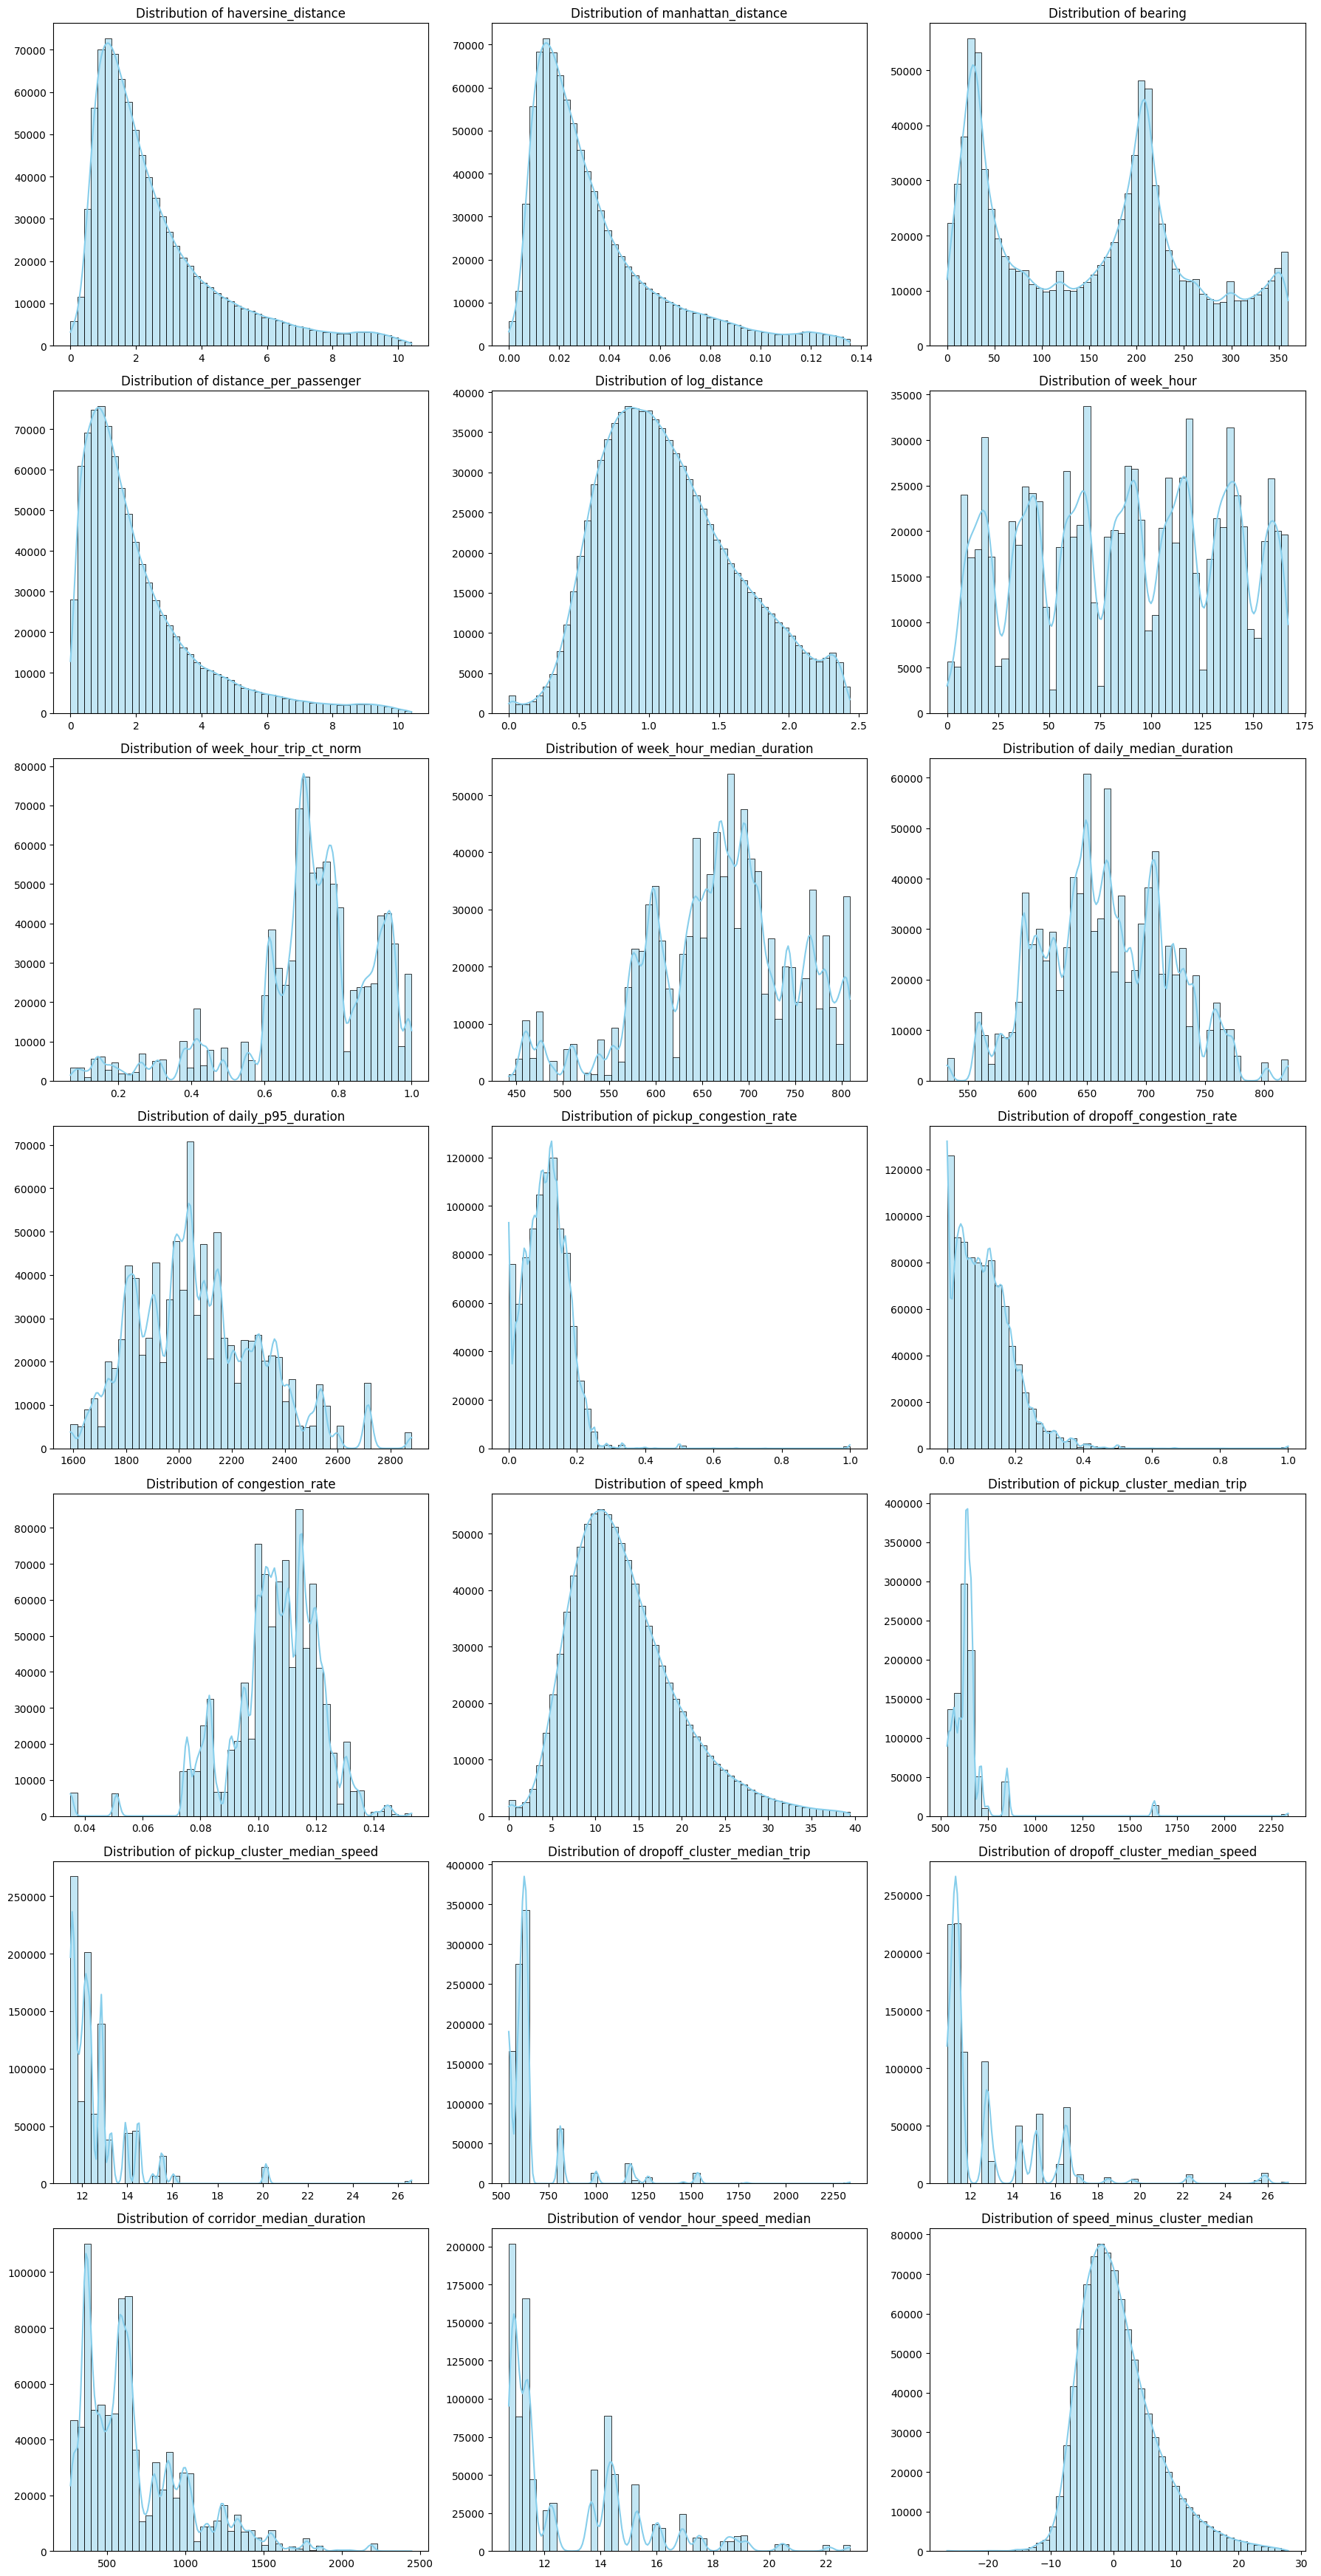

In [28]:
import math

num_cols = feature_lists['numeric']
n_features = len(num_cols)
cols_per_row = 3  # Increased for better use of space
rows = math.ceil(n_features / cols_per_row)

plt.figure(figsize=(18, 5 * rows))
for i, col in enumerate(num_cols, 1):
    plt.subplot(rows, cols_per_row, i)
    # Using a smaller sample if the dataset is massive to speed up KDE calculation
    sns.histplot(df_processed[col], bins=50, kde=True, color='skyblue')
    plt.title(f'Distribution of {col}', fontsize=12)
    plt.xlabel('')
    plt.ylabel('')

plt.tight_layout()
plt.show()

### **Visual Validation Results**

The distributions confirm that we have successfully:

1. **Minimized Skewness** in distance features.
2. **Identified Periodicity** in temporal features.
3. **Centered Residuals** (like speed delta) around zero, ensuring our benchmarks are statistically sound.

In [ ]:
sns.pairplot(df_processed[feature_lists['numeric']])
plt.show()

In [29]:
df_processed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 910076 entries, 0 to 910075
Data columns (total 60 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   pickup_longitude             910076 non-null  float64
 1   pickup_latitude              910076 non-null  float64
 2   dropoff_longitude            910076 non-null  float64
 3   dropoff_latitude             910076 non-null  float64
 4   store_and_fwd_flag           910076 non-null  object 
 5   trip_duration                910076 non-null  int64  
 6   pickup_date                  910076 non-null  object 
 7   is_holiday                   910076 non-null  int64  
 8   dayofweek                    910076 non-null  int64  
 9   month                        910076 non-null  int64  
 10  hour                         910076 non-null  int64  
 11  day                          910076 non-null  int64  
 12  rush_hours                   910076 non-null  int64  
 13 

In [30]:
df_processed['store_and_fwd_flag'] = df_processed['store_and_fwd_flag'].map({'N': 0, 'Y': 1})

/tmp/ipykernel_48461/311394149.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_corr['log_transformed_trip_duration'] = np.log1p(df_processed['trip_duration'])


<Axes: >

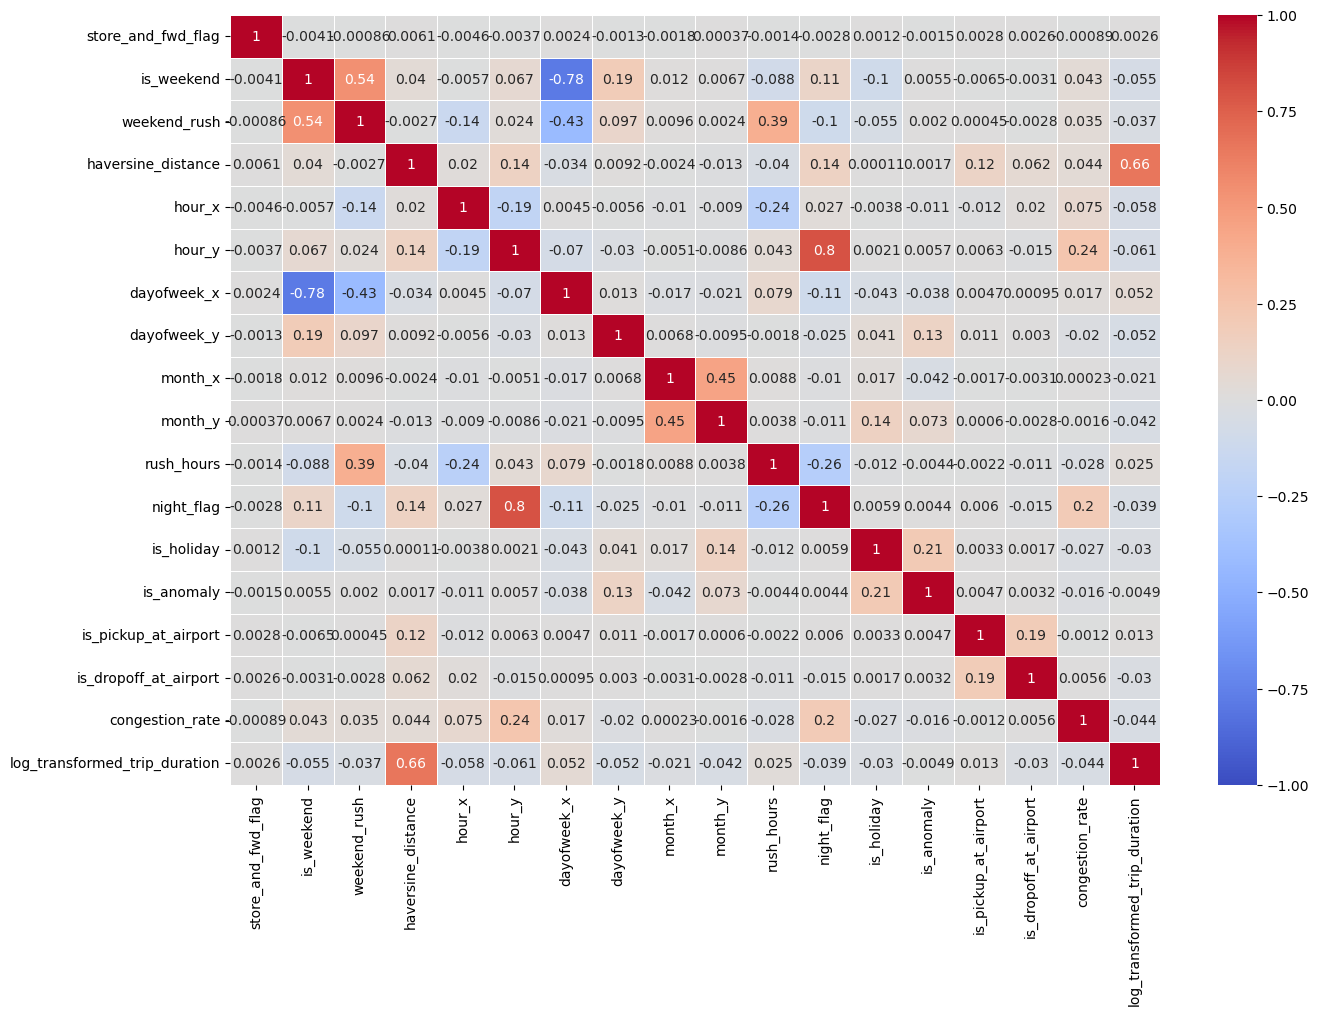

In [31]:
df_processed["weekend_rush"] = df_processed["is_weekend"] * df_processed["rush_hours"]
df_corr = df_processed[['store_and_fwd_flag','is_weekend','weekend_rush','haversine_distance','hour_x','hour_y','dayofweek_x','dayofweek_y','month_x','month_y','rush_hours','night_flag','is_holiday','is_anomaly','is_pickup_at_airport','is_dropoff_at_airport','congestion_rate']]
df_corr['log_transformed_trip_duration'] = np.log1p(df_processed['trip_duration'])
corr = df_corr.corr()

fig = plt.figure(figsize=(15,10))
sns.heatmap(corr,annot=True,linewidths=0.5,cmap='coolwarm',vmin=-1,vmax=1,center=0)